<a href="https://colab.research.google.com/github/shreyanariya15/AI-ML-TRAIINING-/blob/main/Analysis_uni_bi_multi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Univariate, bivariate, and multivariate analysis are statistical methods that look at one, two, or many variables at the same time.

- Univariate analysis: Looks at only one variable or column of data by itself to find basic patterns like averages or counts.
- Bivariate analysis: Looks at two variables together to see if and how they affect each other.
- Multivariate analysis: Looks at three or more variables at the same time to understand complex real-world connections.

- Simple Breakdown of Each Type
- > Univariate Analysis
   - >Focus: One variable at a time.
   - >Goal: Describe the data and find basic shapes or totals.
   - >Common tools: Bar charts, pie charts, histograms, averages, and percentages.
   - >Example: Finding the average age of students in a class
     
- > Bivariate Analysis
   - > Focus: Two variables at the same time.
   - > Goal: Find a link, connection, or cause between two things.
   - > Common tools: Scatter plots, cross-tabulation tables, and simple correlation.
   - > Example: Checking if study hours (variable 1) change test scores (variable 2).
     >
     >
- Multivariate Analysis
   - > Focus: Three or more variables at the same time.
   - > Goal: See the big picture and control for hidden or extra factors.
   - > Common tools: Multiple regression, factor analysis, and cluster analysis.
   - > Example: Predicting a house price using size, location, age of the house, and number of rooms all at on

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [ ]:
df = sns.load_dataset("tips")


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 1. Univariate Analysis (1 Variable at a Time)
- Here we look at one variable independently to check central tendency, spread, outliers, or category frequencies.

##### A. Numerical Variable: total_bill
- We want to see the distribution of bill amounts

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64


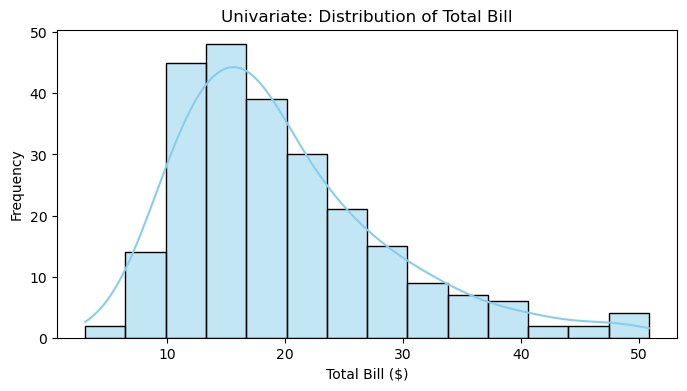

In [ ]:
print(df["total_bill"].describe())

# Visualization: Histogram + KDE (Kernel Density Estimate)
plt.figure(figsize=(8, 4))
sns.histplot(df["total_bill"], kde=True, color="skyblue")
plt.title("Univariate: Distribution of Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Frequency")
plt.show()

##### B. Categorical Variable: day
We want to see how many transactions happen on each day.

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_28372\64174086.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="day", palette="Set2")


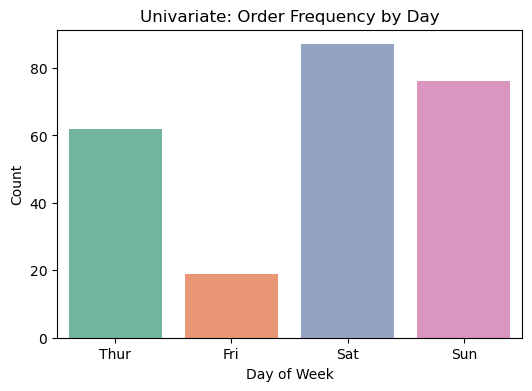

In [ ]:
print(df["day"].value_counts())

# Visualization: Bar Chart / Count Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="day", palette="Set2")
plt.title("Univariate: Order Frequency by Day")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.show()

## 2. Bivariate Analysis (2 Variables Together)

A. Numerical vs. Numerical: total_bill vs. tip
- Do people who pay larger bills leave larger tips?

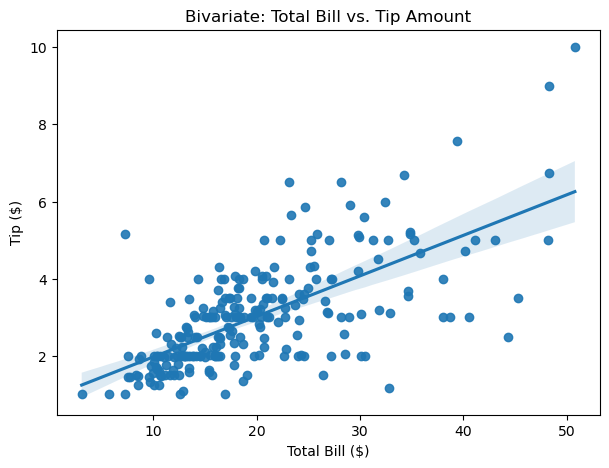

Correlation between Total Bill and Tip: 0.68


In [ ]:
# Scatter Plot + Linear Trend Line
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x="total_bill", y="tip", scatter_kws={"alpha": 0.9})
plt.title("Bivariate: Total Bill vs. Tip Amount")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

# Pearson Correlation Coefficient
correlation = df["total_bill"].corr(df["tip"])
print(f"Correlation between Total Bill and Tip: {correlation:.2f}")

## B. Categorical vs. Numerical: day vs. total_bill

C:\Users\lenovo\AppData\Local\Temp\ipykernel_28372\7289004.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="day", y="total_bill", palette="Set3")


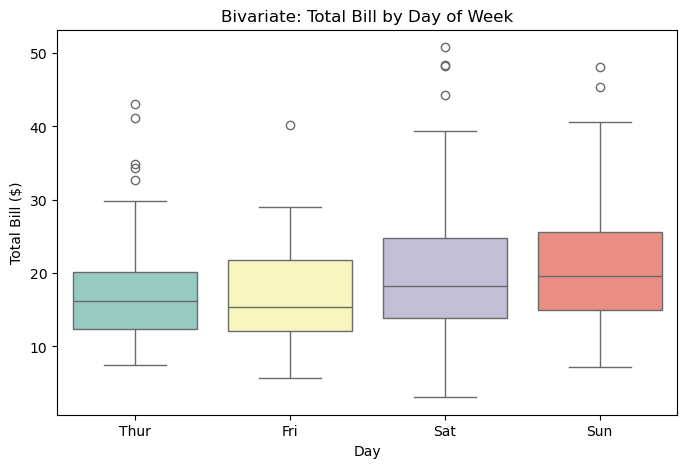

In [ ]:
# Boxplot to compare distributions across groups
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="day", y="total_bill", palette="Set3")
plt.title("Bivariate: Total Bill by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Bill ($)")
plt.show()

## 3. Multivariate Analysis (3+ Variables Together)
- Multivariate analysis reveals complex interactions by examining three or more features at once.

- One popular way to view multiple bivariate relationships at once across groups is a Pair Plot:

#### A. 3 Variables: total_bill vs. tip split by smoker status

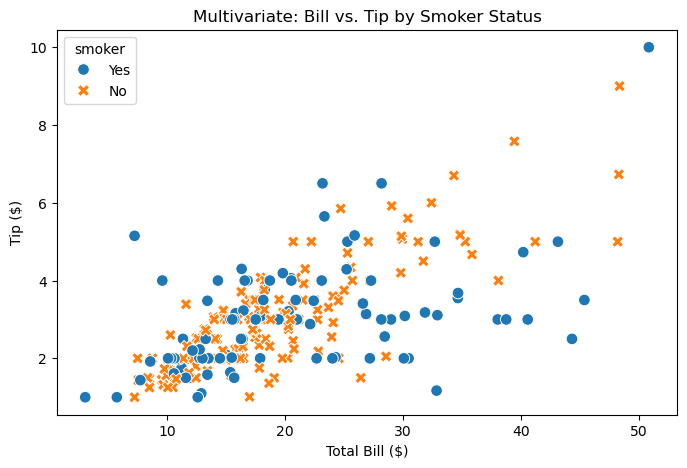

In [ ]:
# Scatter plot hue mapping (3 variables: total_bill, tip, smoker)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="smoker",
    style="smoker",
    s=70,
)
plt.title("Multivariate: Bill vs. Tip by Smoker Status")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

#### B. Correlation Heatmap (All Numerical Variables)
- Analyze relationships across total_bill, tip, and size (party size) simultaneously.

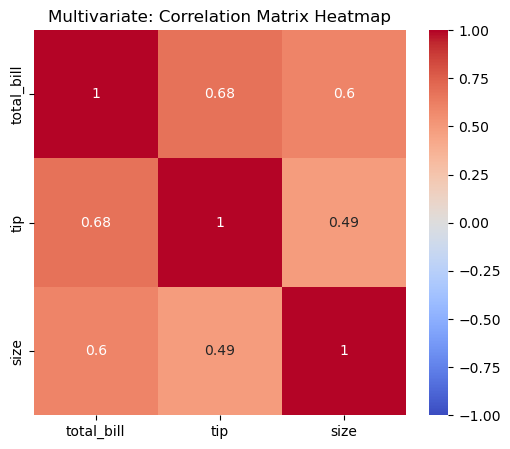

In [ ]:
# Compute correlation matrix for numeric columns
numeric_df = df.select_dtypes(include=["float64", "int64"])
corr_matrix = numeric_df.corr()

# Heatmap visualization
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Multivariate: Correlation Matrix Heatmap")
plt.show()